LAB 7: Develop a simple linear regression model, extend it
to multiple linear regression with several variables, and visualize both the regression
line and residual plots


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Generate synthetic data for simple linear regression
np.random.seed(42)
X_simple = np.random.rand(100, 1) * 10 # Feature
y_simple = 3 * X_simple + 7 + np.random.randn(100, 1) * 2 # Target with noise
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)
# Build and train the simple linear regression model
simple_lr = LinearRegression()
simple_lr.fit(X_train, y_train)
# Predict on test data
y_pred_simple = simple_lr.predict(X_test)
simple_lr.fit(X_train, y_train)
# Predict on test data
y_pred_simple = simple_lr.predict(X_test)

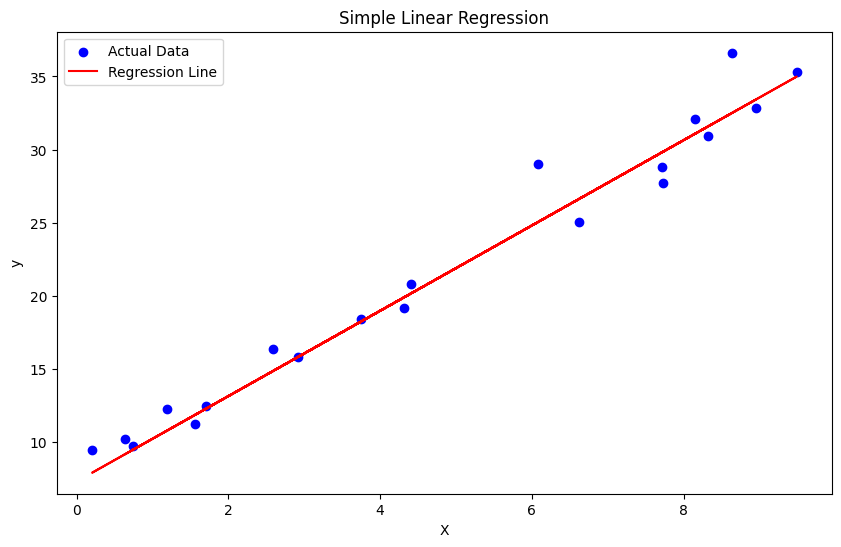

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred_simple, color='red', label='Regression Line')
plt.title('Simple Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


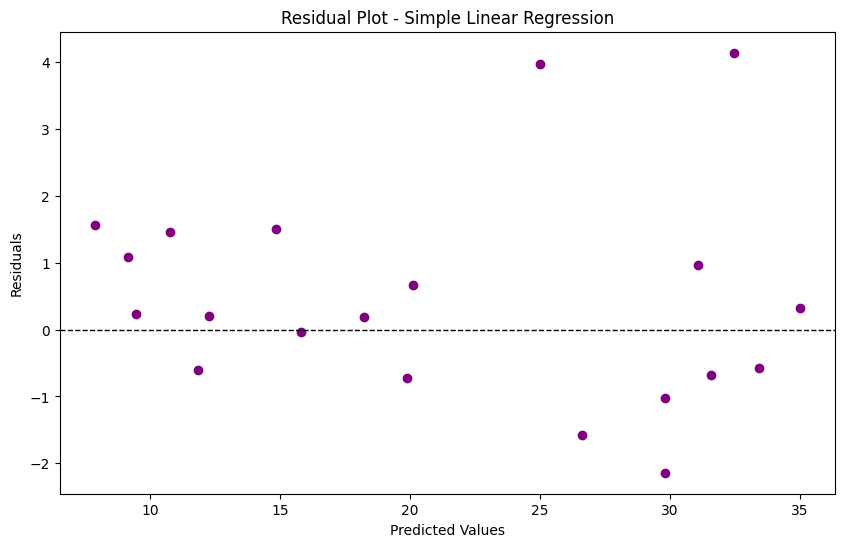

In [ ]:
residuals_simple = y_test - y_pred_simple
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_simple, residuals_simple, color='purple')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot - Simple Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [ ]:
np.random.seed(42)
X_multi = np.random.rand(100, 3) * 10 # 3 features
y_multi = 4 * X_multi[:, 0] + 3 * X_multi[:, 1] - 2 * X_multi[:, 2] + 5 + np.random.randn(100)
# Split the data
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi)
# Build and train the multiple linear regression model
multi_lr = LinearRegression()
multi_lr.fit(X_train_multi, y_train_multi)
# Predict on test data
y_pred_multi = multi_lr.predict(X_test_multi)

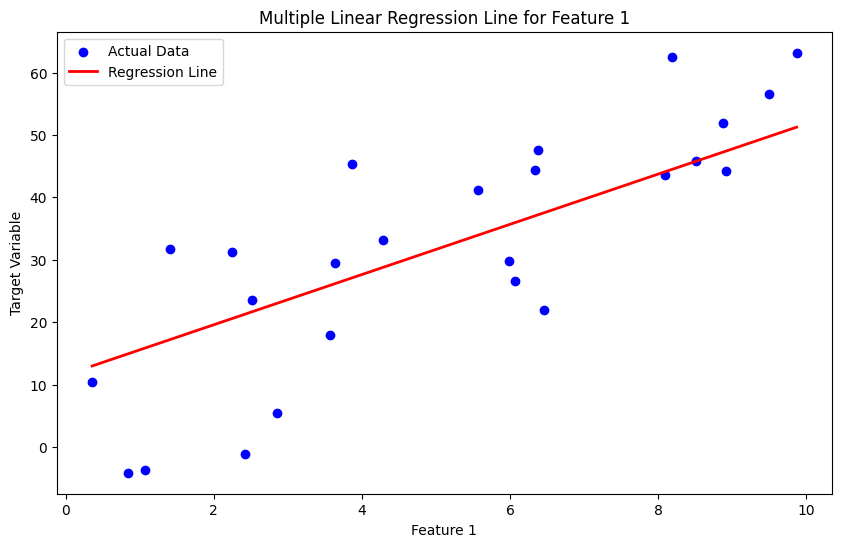

In [ ]:
# Choose one feature to plot (e.g., Feature 0)
feature_index = 0 # Index of the feature to visualize
# Choose one feature to plot (e.g., Feature 0)
feature_index = 0 # Index of the feature to visualize
fixed_features = np.mean(X_test_multi, axis=0) # Fix other features at their mean values
# Generate values for the selected feature
x_values = np.linspace(X_test_multi[:, feature_index].min(), X_test_multi[:, feature_index].max(), 100).reshape(-1,1)
# Create data points for predictions by fixing other features
X_plot = np.tile(fixed_features, (x_values.shape[0], 1)) # Copy fixed features
X_plot[:, feature_index] = x_values[:, 0] # Replace the selected feature with varying value
# Predict using the model
y_plot = multi_lr.predict(X_plot)
# Scatter plot of actual data points for the selected feature
plt.figure(figsize=(10, 6))
plt.scatter(X_test_multi[:, feature_index], y_test_multi, color='blue', label='Actual Data')
# Plot the regression line
plt.plot(x_values, y_plot, color='red', label='Regression Line', linewidth=2)
# Add labels and title
plt.title(f'Multiple Linear Regression Line for Feature {feature_index + 1}')
plt.xlabel(f'Feature {feature_index + 1}')
plt.ylabel('Target Variable')
plt.legend()
plt.show()


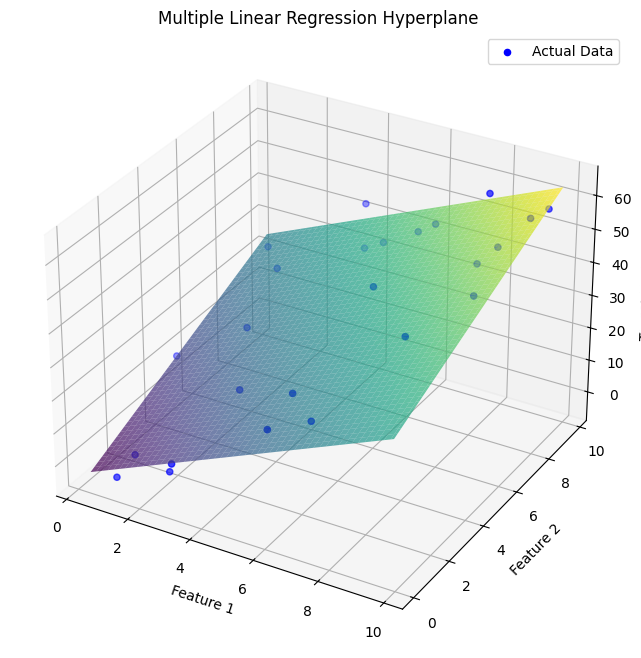

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
# Choose two features to plot (e.g., Features 0 and 1)
feature_indices = [0, 1] # Indices of the features to visualize
from mpl_toolkits.mplot3d import Axes3D
# Choose two features to plot (e.g., Features 0 and 1)
feature_indices = [0, 1] # Indices of the features to visualize
fixed_features = np.mean(X_test_multi, axis=0) # Fix other features at their mean values
# Generate a grid of values for the selected features
x1_values = np.linspace(X_test_multi[:, feature_indices[0]].min(), X_test_multi[:, feature_indices[0]].max(), 100)
x2_values = np.linspace(X_test_multi[:, feature_indices[1]].min(), X_test_multi[:, feature_indices[1]].max(), 100)
x1_grid, x2_grid = np.meshgrid(x1_values, x2_values)
# Create data points for predictions by fixing other features
X_plot = np.tile(fixed_features, (x1_grid.size, 1)) # Copy fixed features
X_plot[:, feature_indices[0]] = x1_grid.ravel() # Replace feature 1
X_plot[:, feature_indices[1]] = x2_grid.ravel() # Replace feature 2
# Predict using the model
y_plot = multi_lr.predict(X_plot).reshape(x1_grid.shape)
# Create a 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
# Plot the surface
ax.plot_surface(x1_grid, x2_grid, y_plot, cmap='viridis', alpha=0.7)
# Scatter the actual data points
ax.scatter(X_test_multi[:, feature_indices[0]], X_test_multi[:, feature_indices[1]], y_test_multi, color='blue', label='Actual Data')
# Add labels and title
ax.set_title('Multiple Linear Regression Hyperplane')
ax.set_xlabel(f'Feature {feature_indices[0] + 1}')
ax.set_ylabel(f'Feature {feature_indices[1] + 1}')
ax.set_zlabel('Target Variable')
plt.legend()
plt.show()


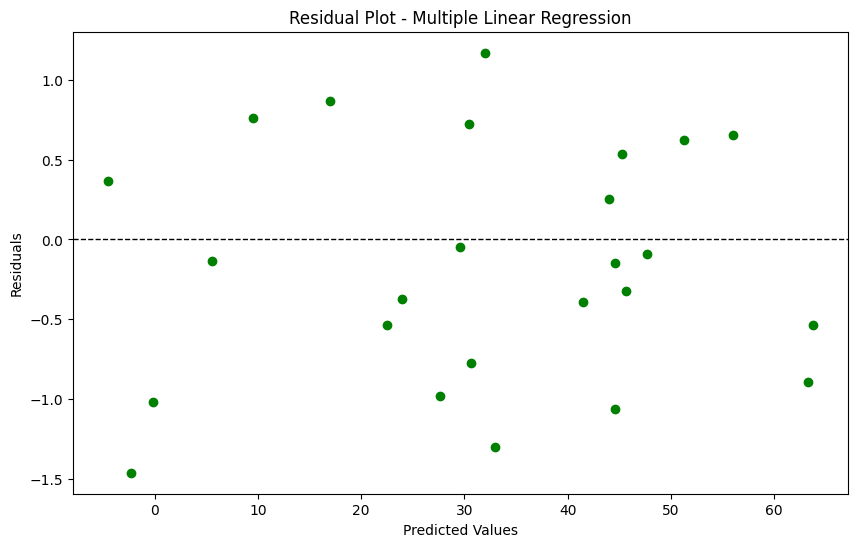

In [ ]:
residuals_multi = y_test_multi - y_pred_multi
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_multi, residuals_multi, color='green')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot - Multiple Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [ ]:
print("Simple Linear Regression Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_simple):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_simple):.2f}\n")
print("Multiple Linear Regression Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test_multi, y_pred_multi):.2f}")
print(f"R2 Score: {r2_score(y_test_multi, y_pred_multi):.2f}")


Simple Linear Regression Metrics:
Mean Squared Error: 2.61
R2 Score: 0.97

Multiple Linear Regression Metrics:
Mean Squared Error: 0.56
R2 Score: 1.00


Lab 8: Apply logistic regression and evaluate the model using metrics such as accuracy,
precision, recall, and the ROC curve

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
confusion_matrix,
roc_curve,
auc,
classification_report,
)
# Generate synthetic data for binary classification
np.random.seed(42)
X = np.random.rand(200, 2) * 10 # 2 features
y = (4 * X[:, 0] - 3 * X[:, 1] + np.random.randn(200) > 0).astype(int) # Binary target
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Build and train the logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
# Predict on the test set
y_pred = log_reg.predict(X_test)
y_pred_prob = log_reg.predict_proba(X_test)[:, 1] # Probabilities for the positive class
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.98
Precision: 0.97
Recall: 1.00


In [ ]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.98
Precision: 0.97
Recall: 1.00


In [ ]:
# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)



Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        22
           1       0.97      1.00      0.99        38

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


Confusion Matrix:
 [[21  1]
 [ 0 38]]


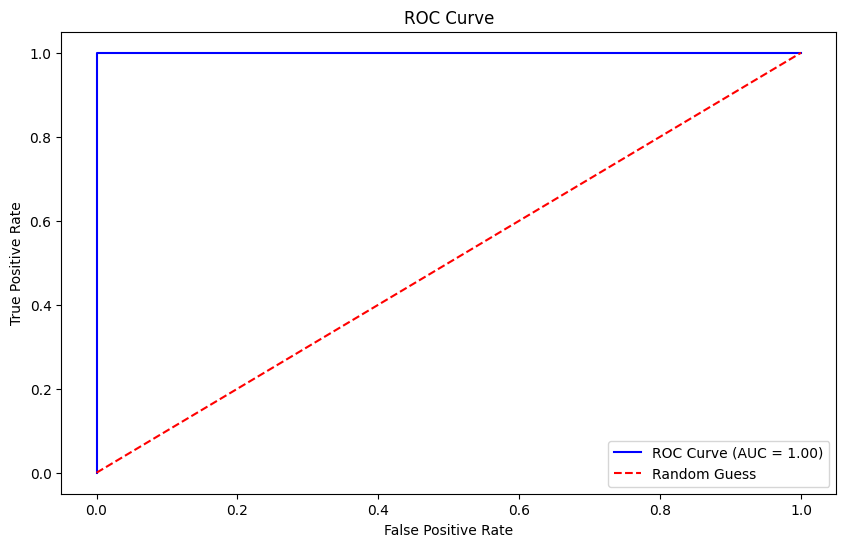

In [ ]:
# Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob) # False Positive Rate, True Positive Rate
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color="blue", label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

LAB 9: Apply K-means clustering and assess cluster quality using evaluation metrics
like the silhouette score


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
# Generate some example data (you can replace this with your own dataset)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
# Apply K-means clustering
kmeans = KMeans(n_clusters=4, random_state=500)
kmeans.fit(X)
# Get the predicted clusters
clusters = kmeans.predict(X)

In [ ]:
# Calculate the silhouette score
sil_score = silhouette_score(X, clusters)
print(f'Silhouette Score: {sil_score}')


Silhouette Score: 0.6819938690643478


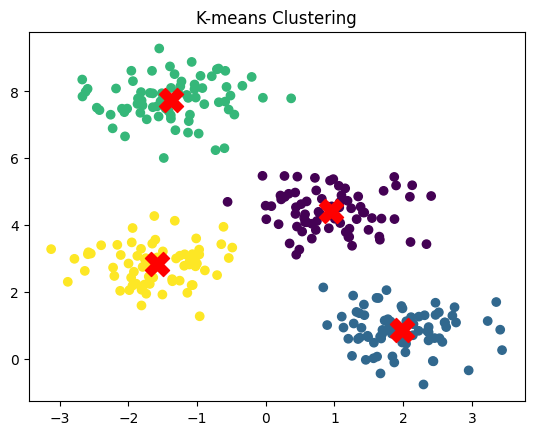

In [ ]:
# Plot the clustered data
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X')
plt.title('K-means Clustering')
plt.show()